# Phase 3: Feature Engineering

**Author:** Taline Zeidan  
**Course:** COE 546 — Machine Learning, Spring 2026  
**Input:** `data/train_preprocessed.csv`, `data/test_preprocessed.csv`  
**Output:** `data/train_features.csv`, `data/test_features.csv`

---

## Objectives

Raw features rarely capture the full picture. This notebook creates **derived features** that encode domain knowledge about user behavior and promo effectiveness — going beyond what the raw columns express individually.

Feature engineering is guided by the EDA findings from Phase 1:
- The strongest numeric predictors are `session_duration_s`, `inactivity_gap_s`, and `promos_shown`
- `promo_response = ACCEPTED` has a 24.3% order rate vs 0.7% for DECLINED — the highest categorical signal
- `promo_type = S` has a 37.2% order rate vs ~1–2% for all other types
- Returning customers (`customer_type = OC`) order at 4.2% vs 1.2% for new customers
- **Interaction terms** between these high-signal features are expected to be especially powerful

---

## Encoded Label Reference (from Phase 2)

| Column | Encoding |
|---|---|
| `promo_response` | ACCEPTED=0, DECLINED=1, IGNORED=2, NONE=3 |
| `promo_type` | C=0, F=1, NONE=2, P=3, S=4 |
| `customer_type` | NC=0, OC=1 |
| `action_type` | CART_CHANGE=0, PAGE_LOAD=1 |

## 1. Imports & Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR  = os.path.join(BASE_DIR, 'data')
OUT_DIR   = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

TRAIN_IN  = os.path.join(DATA_DIR, 'train_preprocessed.csv')
TEST_IN   = os.path.join(DATA_DIR, 'test_preprocessed.csv')
TRAIN_OUT = os.path.join(DATA_DIR, 'train_features.csv')
TEST_OUT  = os.path.join(DATA_DIR, 'test_features.csv')

# ── Label encoding reference (from Phase 2) ────────────────────────────────
PROMO_RESPONSE_ACCEPTED = 0   # highest order rate: 24.3%
PROMO_TYPE_S            = 4   # highest order rate: 37.2%
CUSTOMER_TYPE_OC        = 1   # returning customer: 4.2% order rate

print('Paths set up.')
print(f'Train input : {TRAIN_IN}')
print(f'Test input  : {TEST_IN}')

Paths set up.
Train input : c:\Users\User\OneDrive - Lebanese American University\University\SPRING 2026\COE 546 Machine Learning\Term Project\user_prediction_app\data\train_preprocessed.csv
Test input  : c:\Users\User\OneDrive - Lebanese American University\University\SPRING 2026\COE 546 Machine Learning\Term Project\user_prediction_app\data\test_preprocessed.csv


## 2. Load Data

In [2]:
train = pd.read_csv(TRAIN_IN)
test  = pd.read_csv(TEST_IN)

print(f'Train shape: {train.shape}')
print(f'Test shape : {test.shape}')
print(f'\nColumns: {train.columns.tolist()}')
train.head(3)

Train shape: (297236, 19)
Test shape : (99639, 18)

Columns: ['id', 'timezone', 'action_type', 'promos_declined', 'customer_type', 'items_in_cart', 'cart_value', 'promo_type', 'discount_value', 'promos_shown', 'screen_size', 'promo_response', 'order_placed', 'session_duration_s', 'inactivity_gap_s', 'hour_of_day', 'day_of_week', 'is_weekend', 'has_promo']


,id,timezone,action_type,promos_declined,customer_type,items_in_cart,cart_value,promo_type,discount_value,promos_shown,screen_size,promo_response,order_placed,session_duration_s,inactivity_gap_s,hour_of_day,day_of_week,is_weekend,has_promo
0,0,420,1,0,0,0,0.0,1,10.0,1.0,1048576.0,2,0,1800.0,456.192,0,1,0,1
1,2,480,1,0,0,0,0.0,3,75.0,1.0,1048576.0,2,0,1800.0,319.072,7,4,0,1
2,3,480,1,0,0,0,0.0,3,10.0,1.0,1048576.0,2,0,1800.0,580.264,14,0,0,1


## 3. Feature Engineering

We create features in 4 groups:

| Group | Features | Rationale |
|---|---|---|
| **Engagement** | `engagement_ratio`, `active_time_s` | Captures how actively the user engaged during the session |
| **Promo effectiveness** | `promo_accepted`, `is_promo_type_S`, `discount_attractiveness`, `cart_qualifies_for_promo` | EDA showed promo type and response are among the highest-signal categorical features |
| **Customer context** | `is_returning_customer`, `is_high_activity_session` | Returning customers order 3.5× more than new customers |
| **Interaction terms** | `returning_x_promo_accepted`, `returning_x_session_duration`, `items_x_duration`, `promo_engagement_score` | Combinations of top signals — trees benefit from explicit interactions |

### 3.1 Engagement Features

- **`engagement_ratio`**: What fraction of the session was the user inactive? `inactivity_gap_s / session_duration_s`. A ratio near 1 means the user stopped interacting early — a signal of disengagement.
- **`active_time_s`**: Actual active time in the session = `session_duration_s - inactivity_gap_s`. Separates truly engaged sessions from sessions where the app was left open.

In [3]:
def add_engagement_features(df):
    # Fraction of session spent inactive (clipped to [0,1] to handle edge cases)
    df['engagement_ratio'] = (
        df['inactivity_gap_s'] / (df['session_duration_s'] + 1)
    ).clip(0, 1)
    
    # Actual active time in seconds
    df['active_time_s'] = (df['session_duration_s'] - df['inactivity_gap_s']).clip(lower=0)
    
    return df

train = add_engagement_features(train)
test  = add_engagement_features(test)

print('Engagement features added:')
print(train[['session_duration_s', 'inactivity_gap_s', 'engagement_ratio', 'active_time_s']].describe().round(2))

Engagement features added:
       session_duration_s  inactivity_gap_s  engagement_ratio  active_time_s
count           297236.00         297236.00         297236.00      297236.00
mean              2075.49           1363.99              0.68         711.49
std                998.22            530.89              0.28        1040.70
min               1800.00              1.32              0.00           0.00
25%               1800.00            981.81              0.47         144.67
50%               1800.29           1685.12              0.76         489.37
75%               1985.23           1775.42              0.92        1096.26
max             242637.85           5903.10              1.00      240818.12


### 3.2 Promo Effectiveness Features

- **`promo_accepted`**: Binary flag — did the user explicitly accept the promotion? (promo_response == ACCEPTED=0). This is the single strongest categorical signal from EDA (24.3% order rate).
- **`is_promo_type_S`**: Binary flag for promo type S specifically — it has a 37.2% order rate vs ~1–2% for all other types. It deserves its own explicit signal rather than being buried in the encoded integer.
- **`discount_attractiveness`**: `discount_value / (cart_value + 1)` — how significant is the discount relative to the cart? A high ratio means the promo is very attractive for the current cart.
- **`cart_qualifies_for_promo`**: Binary — does `cart_value >= discount_value`? If the user already qualifies for the promo, the barrier to ordering is lower.

In [4]:
def add_promo_features(df):
    # Did the user accept the promo? (ACCEPTED encoded as 0)
    df['promo_accepted'] = (df['promo_response'] == PROMO_RESPONSE_ACCEPTED).astype(int)
    
    # Is this the high-performing promo type S? (S encoded as 4)
    df['is_promo_type_S'] = (df['promo_type'] == PROMO_TYPE_S).astype(int)
    
    # How attractive is the discount relative to the cart value?
    df['discount_attractiveness'] = df['discount_value'] / (df['cart_value'] + 1)
    
    # Does the cart already meet or exceed the discount value threshold?
    df['cart_qualifies_for_promo'] = (df['cart_value'] >= df['discount_value']).astype(int)
    
    return df

train = add_promo_features(train)
test  = add_promo_features(test)

# Validate: promo_accepted order rate should match EDA (~24.3%)
accepted_order_rate = train[train['promo_accepted'] == 1]['order_placed'].mean() * 100
print(f'Order rate when promo accepted : {accepted_order_rate:.1f}%  (expected ~24.3% from EDA)')
print(f'is_promo_type_S count          : {train["is_promo_type_S"].sum():,}')
print(f'cart_qualifies_for_promo count : {train["cart_qualifies_for_promo"].sum():,}')

Order rate when promo accepted : 24.3%  (expected ~24.3% from EDA)
is_promo_type_S count          : 1,878
cart_qualifies_for_promo count : 154,840


### 3.3 Customer Context Features

- **`is_returning_customer`**: Binary flag for OC (old/returning customer). Returning customers have a 4.2% order rate vs 1.2% for new customers — 3.5× higher.
- **`is_high_activity_session`**: 1 if the user has items in cart AND session duration exceeds the median (1800s). Captures genuinely engaged sessions with purchase intent.

In [5]:
SESSION_DURATION_MEDIAN = train['session_duration_s'].median()

def add_customer_features(df, duration_median):
    # Returning customer flag (OC encoded as 1)
    df['is_returning_customer'] = (df['customer_type'] == CUSTOMER_TYPE_OC).astype(int)
    
    # High activity: items in cart AND long session
    df['is_high_activity_session'] = (
        (df['items_in_cart'] > 0) & 
        (df['session_duration_s'] > duration_median)
    ).astype(int)
    
    return df

train = add_customer_features(train, SESSION_DURATION_MEDIAN)
test  = add_customer_features(test,  SESSION_DURATION_MEDIAN)

# Validate: returning customer order rate should match EDA (~4.2%)
rc_order_rate = train[train['is_returning_customer'] == 1]['order_placed'].mean() * 100
ha_order_rate = train[train['is_high_activity_session'] == 1]['order_placed'].mean() * 100
print(f'Returning customer order rate    : {rc_order_rate:.1f}%  (expected ~4.2% from EDA)')
print(f'High activity session order rate : {ha_order_rate:.1f}%')
print(f'Session duration median used     : {SESSION_DURATION_MEDIAN:.1f}s')

Returning customer order rate    : 4.2%  (expected ~4.2% from EDA)
High activity session order rate : 16.7%
Session duration median used     : 1800.3s


### 3.4 Interaction Terms

Interaction features multiply two high-signal features together. While tree-based models can learn interactions implicitly, providing them explicitly reduces the depth needed and can meaningfully improve AUC.

- **`returning_x_promo_accepted`**: Returning customer who also accepted a promo — the combination of the two strongest signals. Expected to be the highest-signal engineered feature.
- **`returning_x_session_duration`**: Returning customer × session length — engaged loyal user.
- **`items_x_duration`**: Items in cart × session duration — captures purchase intent weighted by engagement.
- **`promo_engagement_score`**: Composite score combining `has_promo`, `promo_accepted`, and `promos_shown` — a single number capturing overall promo engagement.

In [6]:
def add_interaction_features(df):
    # Top two signals combined
    df['returning_x_promo_accepted'] = df['is_returning_customer'] * df['promo_accepted']
    
    # Returning customer weighted by session engagement
    df['returning_x_session_duration'] = df['is_returning_customer'] * df['session_duration_s']
    
    # Items in cart weighted by how long the user spent
    df['items_x_duration'] = df['items_in_cart'] * df['session_duration_s']
    
    # Composite promo engagement: 0 if no promo, scales with acceptance and volume
    df['promo_engagement_score'] = (
        df['has_promo'] * (df['promo_accepted'] + 1) * df['promos_shown']
    )
    
    return df

train = add_interaction_features(train)
test  = add_interaction_features(test)

# Validate: returning_x_promo_accepted should have very high order rate
rxpa_rate = train[train['returning_x_promo_accepted'] == 1]['order_placed'].mean() * 100
print(f'returning_x_promo_accepted order rate: {rxpa_rate:.1f}%')
print(f'Count of returning + promo accepted  : {train["returning_x_promo_accepted"].sum():,}')

returning_x_promo_accepted order rate: 24.0%
Count of returning + promo accepted  : 5,605


## 4. Final Feature Set Overview

In [7]:
FEATURE_COLS = [c for c in train.columns if c not in ['id', 'order_placed']]

print(f'Total features: {len(FEATURE_COLS)}')
print(f'\nOriginal features (from Phase 1+2):')
original = ['timezone', 'action_type', 'promos_declined', 'customer_type',
            'items_in_cart', 'cart_value', 'promo_type', 'discount_value',
            'promos_shown', 'screen_size', 'promo_response',
            'session_duration_s', 'inactivity_gap_s', 'hour_of_day',
            'day_of_week', 'is_weekend', 'has_promo']
engineered = [c for c in FEATURE_COLS if c not in original]
print(f'  {original}')
print(f'\nEngineered features (Phase 3):')
for f in engineered:
    print(f'  + {f}')

print(f'\nTotal: {len(original)} original + {len(engineered)} engineered = {len(FEATURE_COLS)} features')

Total features: 29

Original features (from Phase 1+2):
  ['timezone', 'action_type', 'promos_declined', 'customer_type', 'items_in_cart', 'cart_value', 'promo_type', 'discount_value', 'promos_shown', 'screen_size', 'promo_response', 'session_duration_s', 'inactivity_gap_s', 'hour_of_day', 'day_of_week', 'is_weekend', 'has_promo']

Engineered features (Phase 3):
  + engagement_ratio
  + active_time_s
  + promo_accepted
  + is_promo_type_S
  + discount_attractiveness
  + cart_qualifies_for_promo
  + is_returning_customer
  + is_high_activity_session
  + returning_x_promo_accepted
  + returning_x_session_duration
  + items_x_duration
  + promo_engagement_score

Total: 17 original + 12 engineered = 29 features


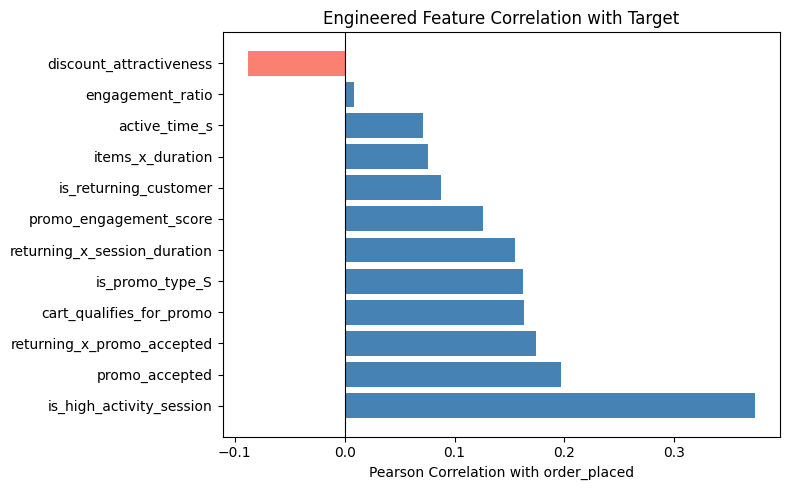

is_high_activity_session        0.3733
promo_accepted                  0.1968
returning_x_promo_accepted      0.1744
cart_qualifies_for_promo        0.1628
is_promo_type_S                 0.1626
returning_x_session_duration    0.1548
promo_engagement_score          0.1257
is_returning_customer           0.0877
items_x_duration                0.0760
active_time_s                   0.0718
engagement_ratio                0.0081
discount_attractiveness        -0.0881
Name: order_placed, dtype: float64


In [8]:
# ── Correlation of NEW features with target ────────────────────────────────
new_feature_corr = train[engineered + ['order_placed']].corr()['order_placed'].drop('order_placed').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if v >= 0 else 'salmon' for v in new_feature_corr.values]
ax.barh(new_feature_corr.index, new_feature_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with order_placed')
ax.set_title('Engineered Feature Correlation with Target')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'engineered_feature_correlation.png'), dpi=150)
plt.show()
print(new_feature_corr.round(4))

## 5. Sanity Checks

In [9]:
# ── Check for NaNs or Infs introduced by feature engineering ──────────────
def check_data_quality(df, name):
    nan_count = df[FEATURE_COLS].isnull().sum().sum()
    inf_count = np.isinf(df[FEATURE_COLS].select_dtypes(include=np.number)).sum().sum()
    print(f'{name}: NaNs={nan_count}, Infs={inf_count}, Shape={df.shape}')
    if nan_count > 0 or inf_count > 0:
        print('  ⚠️  Issues found:')
        nan_cols = df[FEATURE_COLS].isnull().sum()
        print(nan_cols[nan_cols > 0])
    else:
        print('  ✅ Clean')

test_feature_cols = [c for c in FEATURE_COLS if c in test.columns]
check_data_quality(train, 'Train')

# For test, only check feature cols that exist (no order_placed)
nan_count_test = test[test_feature_cols].isnull().sum().sum()
inf_count_test = np.isinf(test[test_feature_cols].select_dtypes(include=np.number)).sum().sum()
print(f'Test : NaNs={nan_count_test}, Infs={inf_count_test}, Shape={test.shape}')
print('  ✅ Clean' if nan_count_test == 0 and inf_count_test == 0 else '  ⚠️  Issues found')

Train: NaNs=0, Infs=0, Shape=(297236, 31)
  ✅ Clean
Test : NaNs=0, Infs=0, Shape=(99639, 30)
  ✅ Clean


## 6. Save Feature-Engineered Data

In [10]:
train.to_csv(TRAIN_OUT, index=False)
test.to_csv(TEST_OUT,   index=False)

print(f'✅ Saved train_features.csv → {train.shape}')
print(f'✅ Saved test_features.csv  → {test.shape}')
print(f'\nFeature columns ({len(FEATURE_COLS)} total):')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

✅ Saved train_features.csv → (297236, 31)
✅ Saved test_features.csv  → (99639, 30)

Feature columns (29 total):
   1. timezone
   2. action_type
   3. promos_declined
   4. customer_type
   5. items_in_cart
   6. cart_value
   7. promo_type
   8. discount_value
   9. promos_shown
  10. screen_size
  11. promo_response
  12. session_duration_s
  13. inactivity_gap_s
  14. hour_of_day
  15. day_of_week
  16. is_weekend
  17. has_promo
  18. engagement_ratio
  19. active_time_s
  20. promo_accepted
  21. is_promo_type_S
  22. discount_attractiveness
  23. cart_qualifies_for_promo
  24. is_returning_customer
  25. is_high_activity_session
  26. returning_x_promo_accepted
  27. returning_x_session_duration
  28. items_x_duration
  29. promo_engagement_score


## 7. Feature Engineering Summary

| Feature | Type | Rationale |
|---|---|---|
| `engagement_ratio` | Engagement | Fraction of session spent inactive — captures disengagement |
| `active_time_s` | Engagement | Actual active time = session_duration - inactivity_gap |
| `promo_accepted` | Promo | Binary: user accepted promo → 24.3% order rate |
| `is_promo_type_S` | Promo | Binary: promo type S → 37.2% order rate, deserves explicit flag |
| `discount_attractiveness` | Promo | discount_value / cart_value — how appealing is the deal |
| `cart_qualifies_for_promo` | Promo | Binary: cart already meets discount threshold |
| `is_returning_customer` | Customer | Binary: OC customers order 3.5× more than NC |
| `is_high_activity_session` | Customer | Items in cart AND long session — strong purchase intent signal |
| `returning_x_promo_accepted` | Interaction | Returning customer + accepted promo — highest-intent combination |
| `returning_x_session_duration` | Interaction | Loyal user engagement weighted by session length |
| `items_x_duration` | Interaction | Purchase intent (items) × engagement time |
| `promo_engagement_score` | Interaction | Composite: has_promo × (accepted+1) × promos_shown |

**Hand-off:** `data/train_features.csv` and `data/test_features.csv` are ready for Phase 4 — Modeling (`04_modeling.ipynb`).